In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("heart.csv")

In [3]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [4]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
print(df.columns)

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')


## DATA VISUALIZATION

### COUNT PLOT

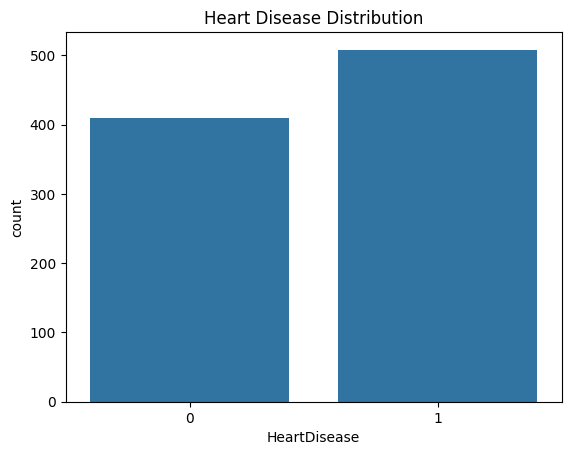

In [7]:
sns.countplot(x='HeartDisease', data=df)

plt.title('Heart Disease Distribution')
plt.show()

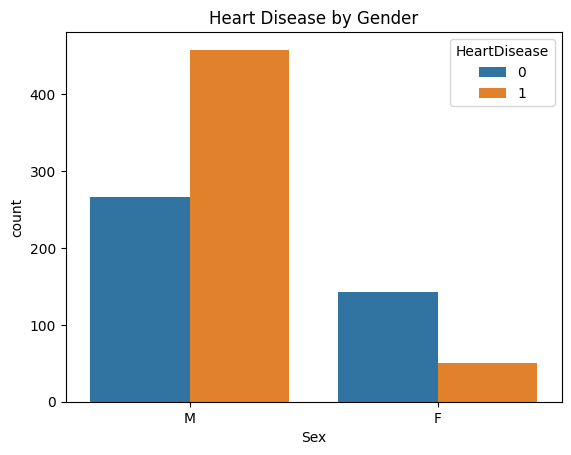

In [8]:
sns.countplot(x='Sex',
              hue='HeartDisease',
              data=df)

plt.title('Heart Disease by Gender')
plt.show()

### HISTOGRAM

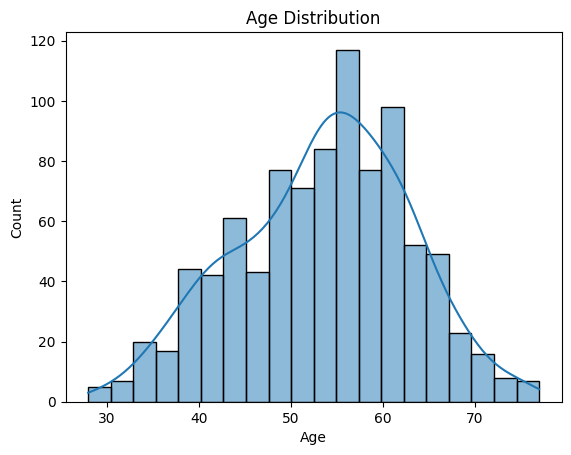

In [9]:
sns.histplot(df['Age'], bins=20, kde=True)

plt.title('Age Distribution')
plt.show()

## BOX PLOT

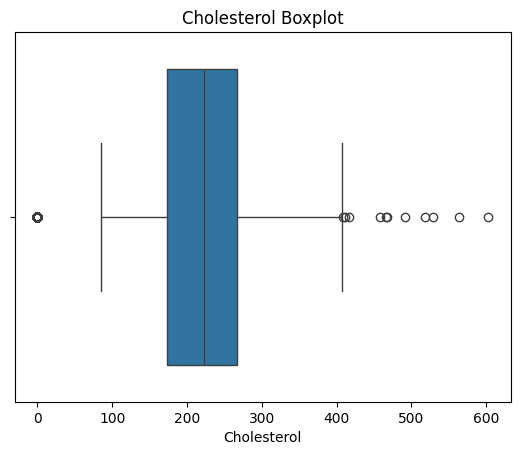

In [10]:
sns.boxplot(x=df['Cholesterol'])

plt.title('Cholesterol Boxplot')
plt.show()

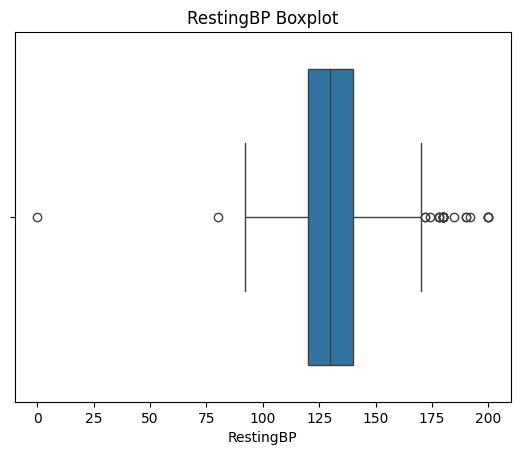

In [11]:
sns.boxplot(x=df['RestingBP'])

plt.title('RestingBP Boxplot')
plt.show()

### PAIR PLOT

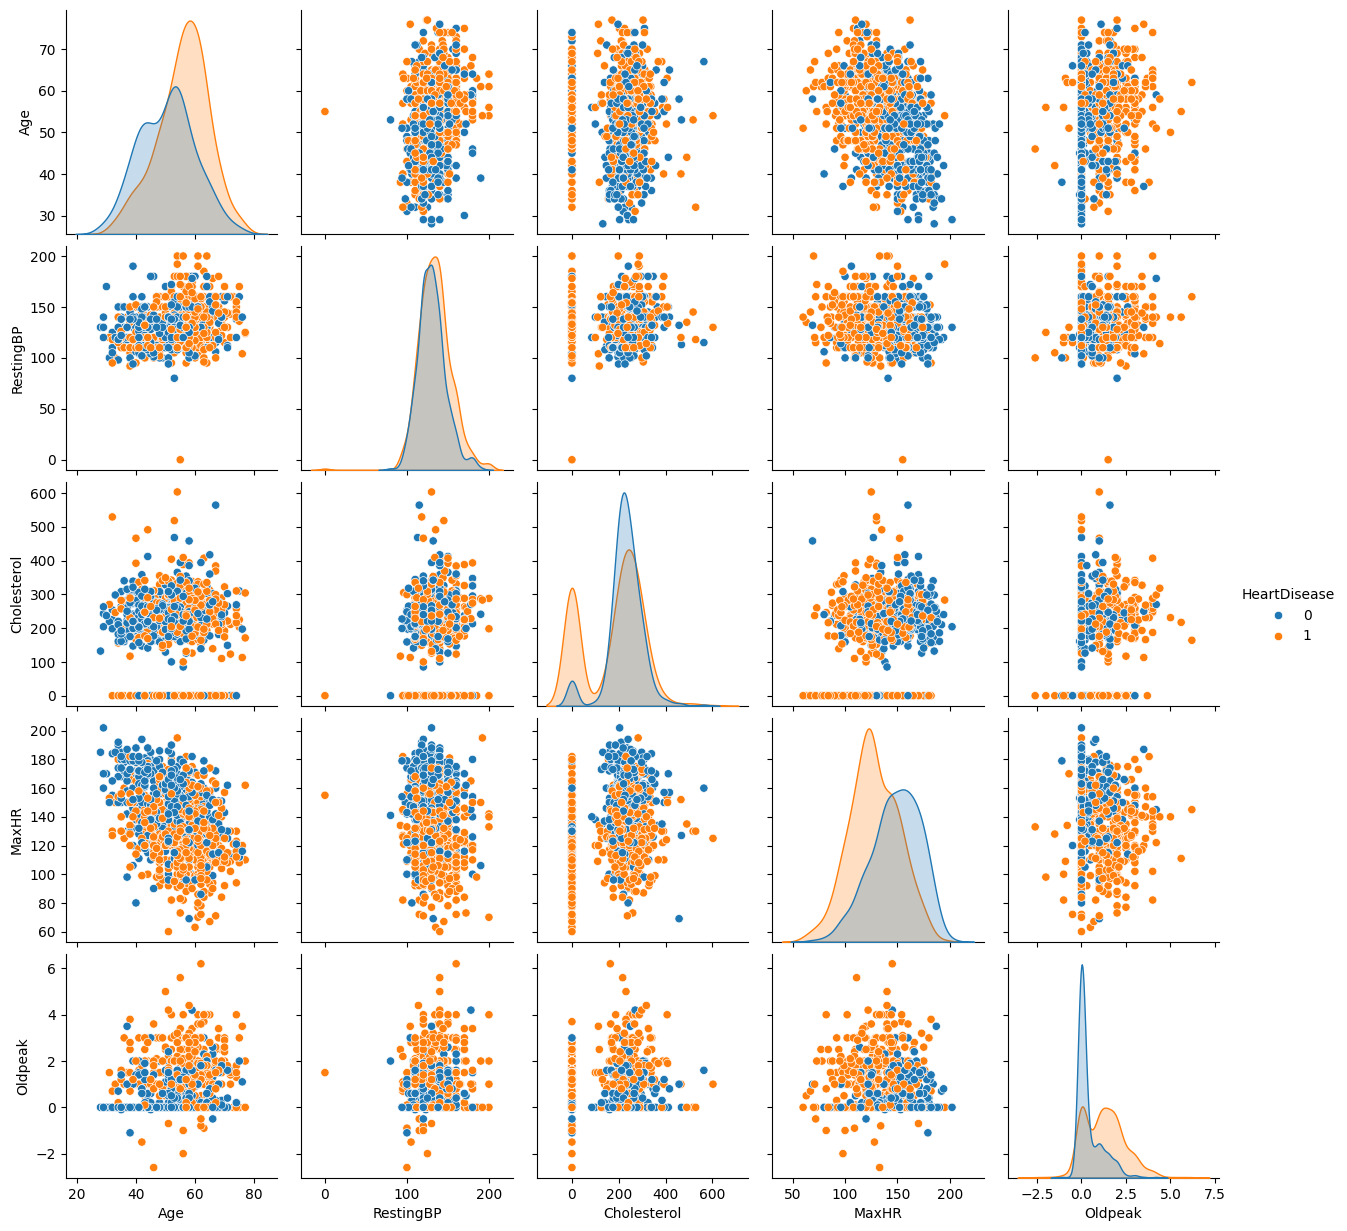

In [12]:
sns.pairplot(
    df[['Age',
        'RestingBP',
        'Cholesterol',
        'MaxHR',
        'Oldpeak',
        'HeartDisease']],
    hue='HeartDisease'
)

plt.show()

### HEATMAP

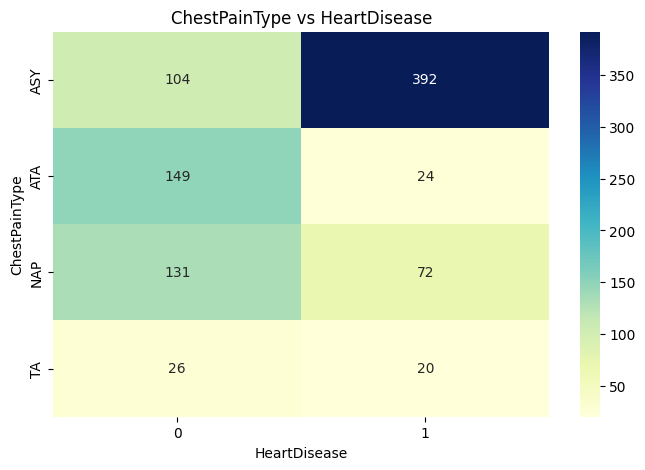

In [13]:
cross_tab = pd.crosstab(df['ChestPainType'],
                        df['HeartDisease'])

plt.figure(figsize=(8,5))
sns.heatmap(cross_tab,
            annot=True,
            cmap='YlGnBu',
            fmt='d')

plt.title('ChestPainType vs HeartDisease')
plt.show()

### DENSITY PLOT

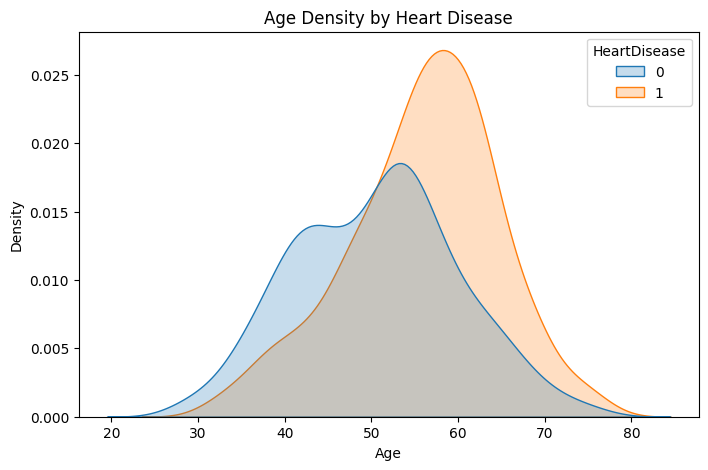

In [14]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x='Age',
    hue='HeartDisease',
    fill=True
)

plt.title('Age Density by Heart Disease')

plt.show()

### LINE PLOT

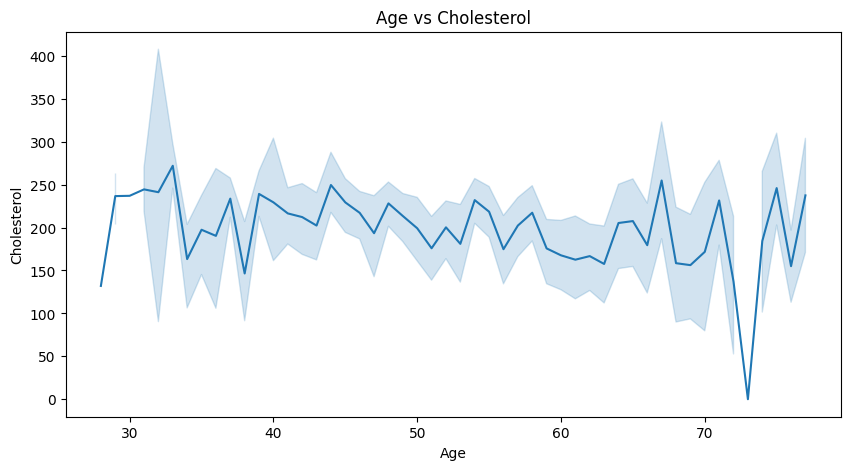

In [15]:
plt.figure(figsize=(10,5))

df_sorted = df.sort_values('Age')

sns.lineplot(
    x='Age',
    y='Cholesterol',
    data=df_sorted
)

plt.title('Age vs Cholesterol')
plt.xlabel('Age')
plt.ylabel('Cholesterol')

plt.show()

### PIE PLOT

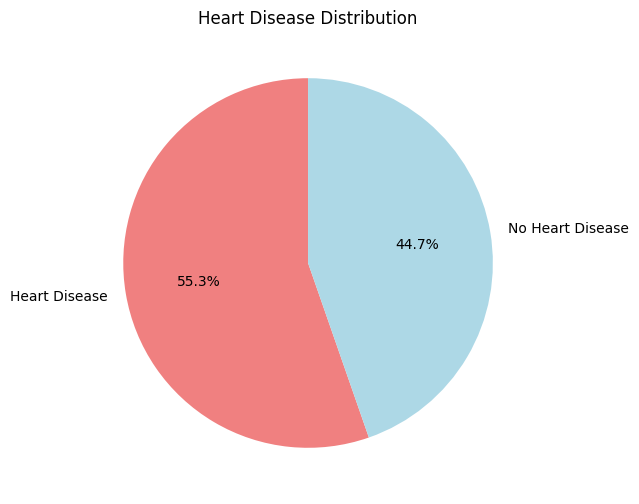

In [16]:
heart_counts = df['HeartDisease'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    heart_counts,
    labels=['Heart Disease', 'No Heart Disease'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightcoral', 'lightblue']
)

plt.title('Heart Disease Distribution')
plt.show()

### SCATTER PLOT

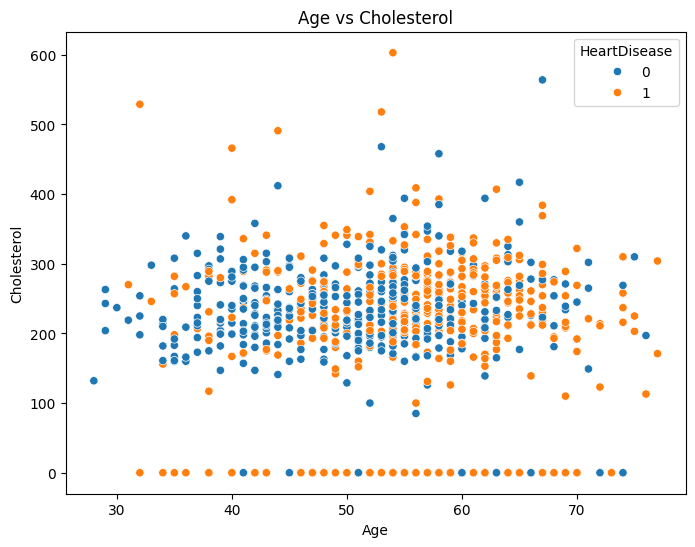

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Age',
    y='Cholesterol',
    hue='HeartDisease',
    data=df
)

plt.title('Age vs Cholesterol')
plt.xlabel('Age')
plt.ylabel('Cholesterol')

plt.show()

### VIOLIN PLOT

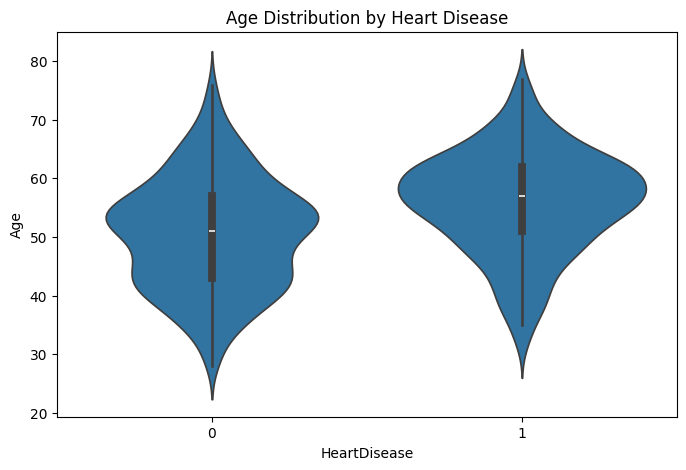

In [18]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x='HeartDisease',
    y='Age',
    data=df
)

plt.title('Age Distribution by Heart Disease')

plt.show()

## FEATURE ENGINEERING

## Separate Features and Target

In [19]:
X = df.drop('HeartDisease', axis=1)

y = df['HeartDisease']

### Identify Categorical Columns

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


### Create New Features

#### Age Group Feature

In [21]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[20,40,60,100],
    labels=['Young','Middle','Senior']
)

#### Cholesterol Category

In [22]:
df['CholesterolLevel'] = pd.cut(
    df['Cholesterol'],
    bins=[0,200,240,600],
    labels=['Normal','Borderline','High']
)

### Average Cholesterol by Age Group

In [23]:
age_chol_avg = df.groupby('AgeGroup')['Cholesterol'].mean()

df['AgeGroup_Cholesterol_Avg'] = df['AgeGroup'].map(age_chol_avg)

### Heart Disease Rate by Chest Pain Type

In [24]:
cp_hd_rate = df.groupby('ChestPainType')['HeartDisease'].mean()

df['ChestPain_HD_Rate'] = df['ChestPainType'].map(cp_hd_rate)

### Average MaxHR by Sex

In [25]:
sex_maxhr_avg = df.groupby('Sex')['MaxHR'].mean()

df['Sex_MaxHR_Avg'] = df['Sex'].map(sex_maxhr_avg)

### Save Engineered Dataset

In [26]:
df.to_csv(
    "feature_engineered_heart.csv",
    index=False
)

In [27]:
print(df.columns)

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease', 'AgeGroup', 'CholesterolLevel',
       'AgeGroup_Cholesterol_Avg', 'ChestPain_HD_Rate', 'Sex_MaxHR_Avg'],
      dtype='str')


## Data Viz

### Count Plot

#### Age Group vs Heart Disease

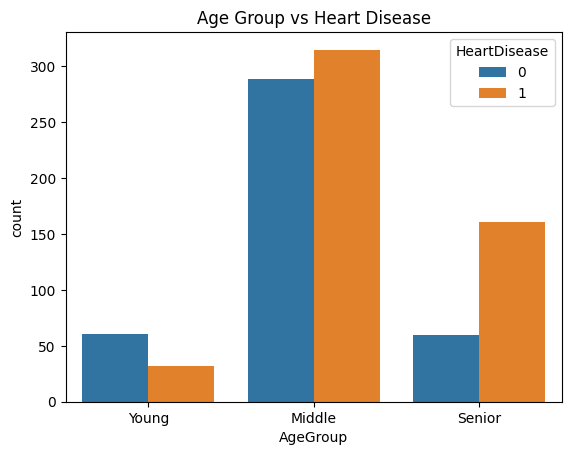

In [28]:
sns.countplot(x='AgeGroup', hue='HeartDisease', data=df)
plt.title('Age Group vs Heart Disease')
plt.show()

### Box Plot

#### MaxHR distribution

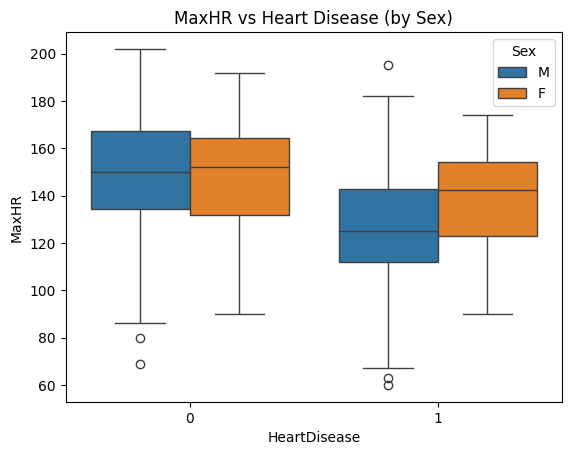

In [29]:
sns.boxplot(x='HeartDisease', y='MaxHR', hue='Sex', data=df)
plt.title('MaxHR vs Heart Disease (by Sex)')
plt.show()

### Scatter Plot

#### Oldpeak vs MaxHR

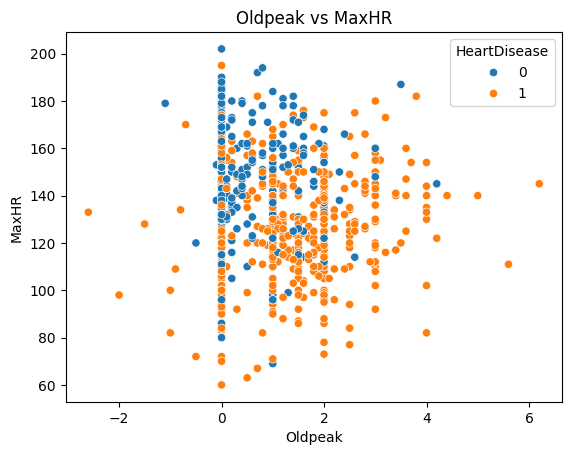

In [30]:
sns.scatterplot(x='Oldpeak', y='MaxHR', hue='HeartDisease', data=df)
plt.title('Oldpeak vs MaxHR')
plt.show()

### Pie Charts

#### Age Group Distribution

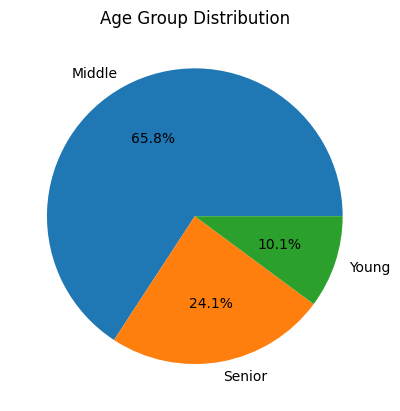

In [31]:
df['AgeGroup'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Age Group Distribution')
plt.ylabel('')
plt.show()

### Violin Plot  

#### Oldpeak vs ST_Slope

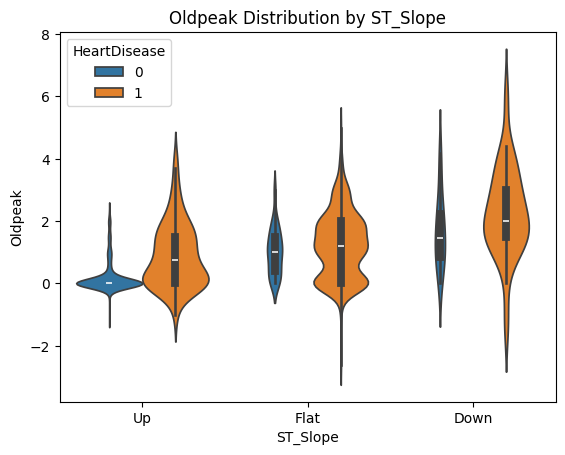

In [32]:
sns.violinplot(x='ST_Slope', y='Oldpeak', hue='HeartDisease', data=df)
plt.title('Oldpeak Distribution by ST_Slope')
plt.show()

## FEATURE SELECTION

### Correlation-Based Selection

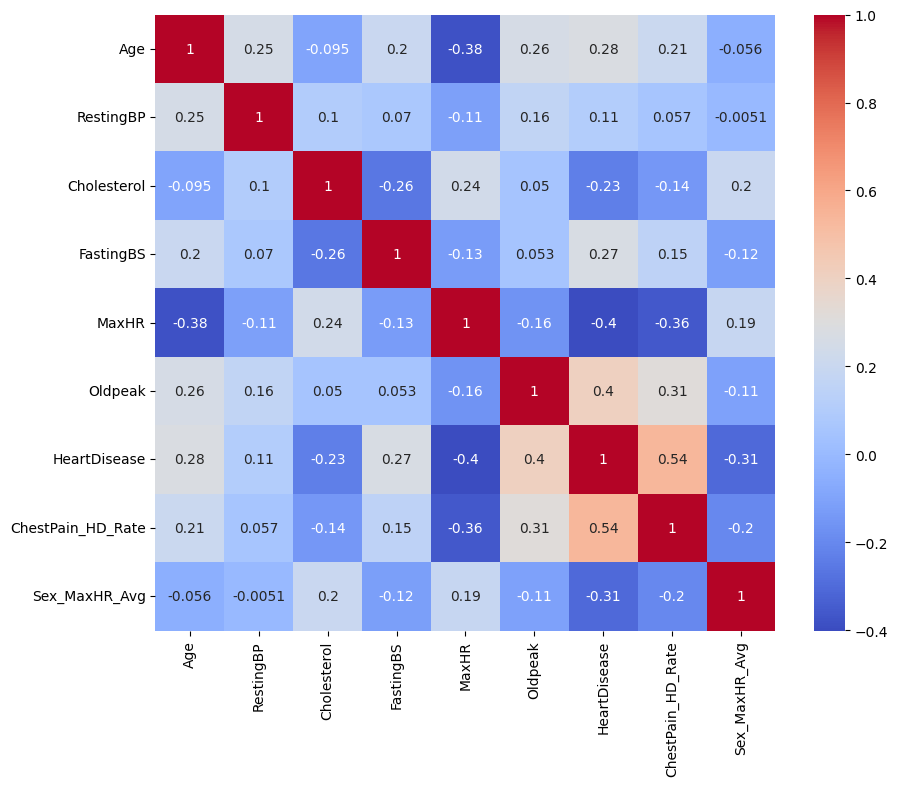

In [33]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

### Apply Encoding

In [34]:
X = pd.get_dummies(X, drop_first=True)

### Model-Based Feature Importance

In [35]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X, y)

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance)


              Feature  Importance
14        ST_Slope_Up    0.164826
2         Cholesterol    0.116246
4               MaxHR    0.111408
5             Oldpeak    0.106008
13      ST_Slope_Flat    0.096959
0                 Age    0.087824
12   ExerciseAngina_Y    0.071825
1           RestingBP    0.070589
7   ChestPainType_ATA    0.043623
6               Sex_M    0.038995
8   ChestPainType_NAP    0.027987
3           FastingBS    0.026600
10  RestingECG_Normal    0.017333
11      RestingECG_ST    0.010791
9    ChestPainType_TA    0.008986


## DATA SPLIT/PARTITIONING

In [37]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Convert categorical → numeric
X = pd.get_dummies(X, drop_first=True)

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## DATA TRANSFORMATION

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## MODEL INITIALIZATION

### Logistic Regression (Baseline)

In [40]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

### Random Forest (Main Model)

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

### SVM

In [42]:
from sklearn.svm import SVC

svm_model = SVC()

## MODEL TRAINING

### Train Logistic Regression

In [43]:
lr_model.fit(X_train, y_train)

c:\Users\nadir\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

### Train Random Forest 

In [44]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

### Train SVM

In [45]:
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## MODEL EVALUATION

### Generate Predictions

In [47]:
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)

### Accuracy Score

In [48]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("SVM:", accuracy_score(y_test, y_pred_svm))

Logistic Regression: 0.8967391304347826
Random Forest: 0.8858695652173914
SVM: 0.6956521739130435


### Classification Report

In [49]:
from sklearn.metrics import classification_report

print("Random Forest Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Report:

              precision    recall  f1-score   support

           0       0.88      0.87      0.87        82
           1       0.89      0.90      0.90       102

    accuracy                           0.89       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



## MODEL VIZ

### Confusion Matrix Visualization

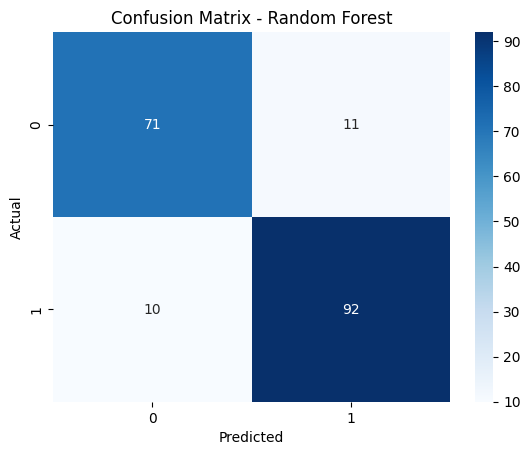

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Feature Importance Plot

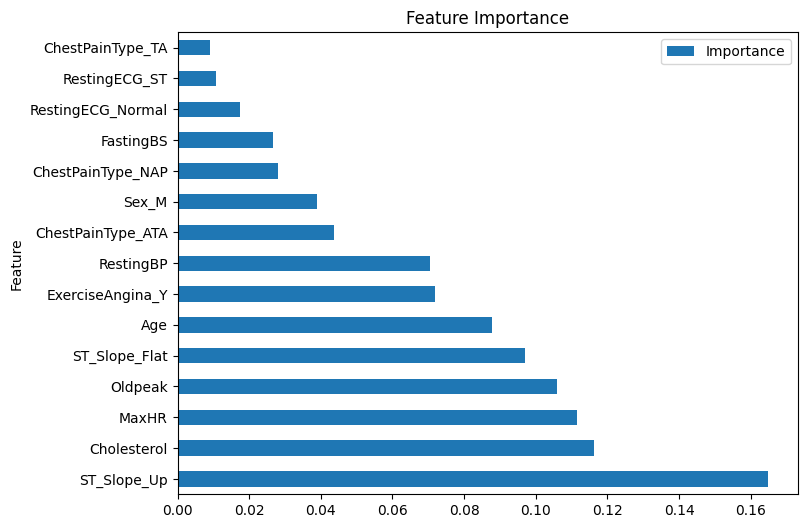

In [51]:
feature_importance.plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(8,6)
)

plt.title('Feature Importance')
plt.show()

### Accuracy Comparison Plot

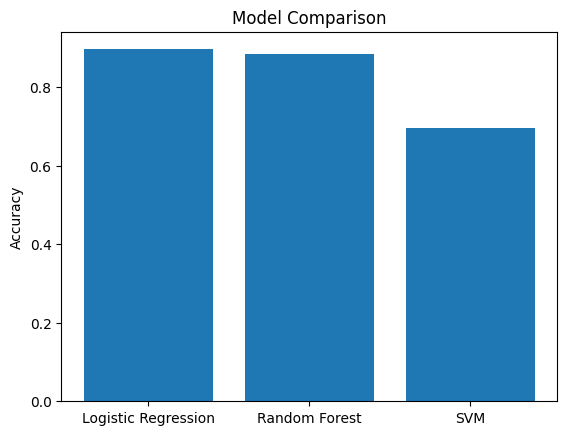

In [52]:
import pandas as pd

models = ['Logistic Regression', 'Random Forest', 'SVM']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_svm)
]

plt.bar(models, accuracies)
plt.title('Model Comparison')
plt.ylabel('Accuracy')
plt.show()

## MODEL DEPLOYMENT

### Save Your Model

In [53]:
import joblib
joblib.dump(rf_model, 'heart_model.pkl')

['heart_model.pkl']

In [54]:
# Save scaler
joblib.dump(scaler, 'scaler.pkl')

# Save column names
joblib.dump(X_train.columns.tolist(), 'columns.pkl')

['columns.pkl']

### Load everything

In [55]:
model = joblib.load('heart_model.pkl')
scaler = joblib.load('scaler.pkl')
columns = joblib.load('columns.pkl')